In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.distributions.empirical_distribution import ECDF
from scipy import stats

from numpy.ma.core import mean, sqrt

In [2]:
#set path + read into dataframe
path = r'../rotterdam_dataset_06.xlsx'
rd = pd.read_excel(path)

#rename for easiness
rd = rd.rename(columns = {'Arrival_Date': 'arrival_date','Vessel_ID':'vessel_id','Vessel_Type':'vessel_type', 'Cargo_tons':'cargo_tons',
                         'Berth_Time_hr':'berth_time_hr'})

# + seaborn style
sns.set_theme(style = 'darkgrid')
palette = sns.color_palette('colorblind')
sns.set_palette('colorblind')

## Arrival Rates (month/day)

In [3]:
#setting up new cols for easy filtering later
rd['year_month_day'] = rd['arrival_date'].dt.strftime('%Y-%m-%d')
rd['year_month'] = rd['arrival_date'].dt.strftime('%Y-%m')
rd['year'] = rd['arrival_date'].dt.strftime('%Y')
rd['month_day'] = rd['arrival_date'].dt.strftime('%m-%d')

#setup grouping for analysis
year_month_count = rd['year_month'].groupby(rd['year_month']).count()
year_month_day_count = rd['year_month_day'].groupby(rd['year_month_day']).count()

In [4]:
print(year_month_count.describe())

#check where min/max are (true/false depending)
#print(rd['year_month'].groupby(rd['year_month']).count().sort_values(ascending = True))
type(year_month_count)

count     36.000000
mean     545.194444
std       78.020444
min      420.000000
25%      484.750000
50%      518.000000
75%      610.250000
max      689.000000
Name: year_month, dtype: float64


pandas.Series

In [5]:
#outlier function from dataquality.py, edited for series-handling
def find_outlier(cont_attr: str, rd = rd):
    '''find outliers via q3/q1 method

    args:
    cont_attr: str - continuous attribute name
    rd: dataframe - rotterdam data; default

    returns:
    outlier: dataframe of outliers
    above_outlier: dataframe of outliers above q3
    below_outlier: dataframe of outliers below q1
    '''
    q3 = rd.quantile(0.75)
    q1 = rd.quantile(0.25)

    #outlier = val>q3 or val<q1
    outlier = rd[(rd > q3) | (rd < q1)]

    #completeness-sake: add above/below outliers to check for inconsistencies
    above_outlier = rd[rd > q3]
    below_outlier = rd[rd < q1]
    
    return outlier, above_outlier, below_outlier

outlier_month, large_outlier_month, small_outlier_month = find_outlier('year_month_count', year_month_count)
outlier_day, large_outlier_day, small_outlier_day = find_outlier('year_month_day_count', year_month_day_count)

In [6]:
print(year_month_day_count.describe())
#avg, median, variance, and std PER DAY
avg_arrival_day = year_month_day_count.mean()
med_arrival_day = year_month_day_count.median()
std_arrival_day = year_month_day_count.std()

#check where min/max are + other suspicious vals
#print(year_month_day_count.sort_values(ascending = True))

count    1096.000000
mean       17.907847
std         4.833076
min         4.000000
25%        14.000000
50%        18.000000
75%        21.000000
max        35.000000
Name: year_month_day, dtype: float64


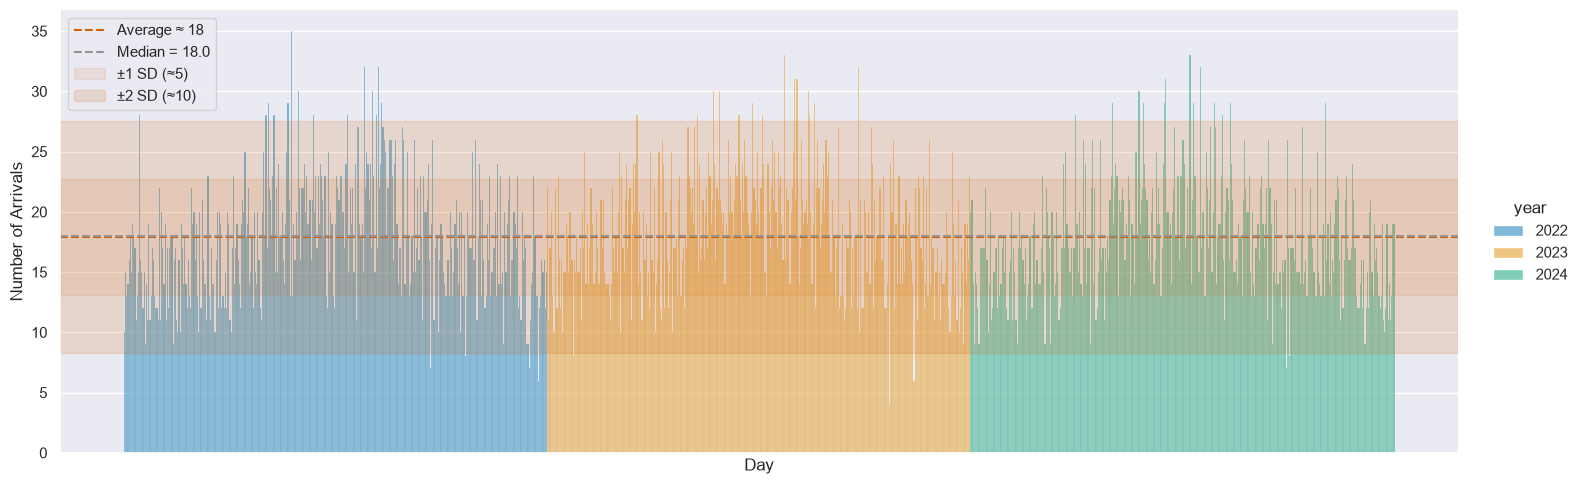

In [7]:
#histogram of per day vessel calls
h = sns.displot(data = rd, x = 'year_month_day', hue = 'year', aspect = 3, kind = 'hist')

#adding a mean line
h.ax.axhline(avg_arrival_day, color = palette[3], linestyle = '--', label = f'Average ≈ {round(avg_arrival_day)}')

#adding a median line => get rid of this if too much
h.ax.axhline(med_arrival_day, color = palette[7], linestyle = '--', label = f'Median = {med_arrival_day}')

#std shading
h.ax.axhspan(avg_arrival_day - std_arrival_day, avg_arrival_day + std_arrival_day, color = palette[3],
             alpha=0.1, label=f'±1 SD (≈{round(std_arrival_day)})')

h.ax.axhspan(avg_arrival_day - 2*std_arrival_day, avg_arrival_day + 2*std_arrival_day, color = palette[3],
             alpha=0.15, label=f'±2 SD (≈{round(2*std_arrival_day)})')

h.ax.legend()
h.ax.set_xticks([])
h.set_axis_labels('Day', 'Number of Arrivals')
h.tight_layout()

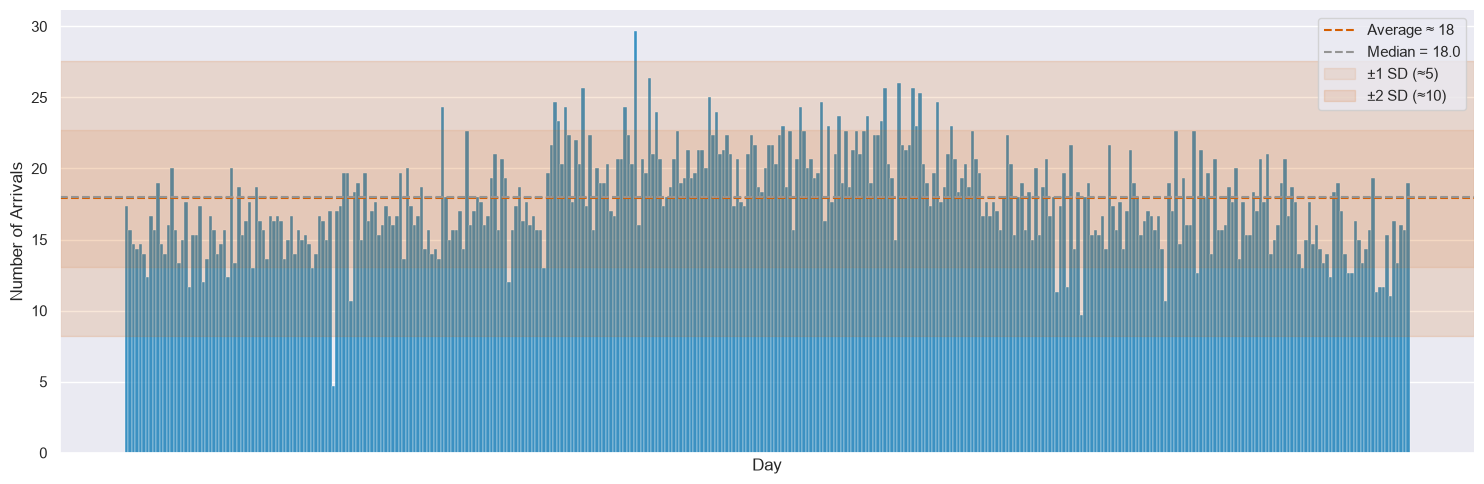

In [8]:
#histogram of per day vessel calls
h = sns.displot(data = rd.sort_values('month_day').assign(w = 1/3), x = 'month_day',
                weights = 'w', aspect = 3, kind = 'hist')

#adding a mean line
h.ax.axhline(avg_arrival_day, color = palette[3], linestyle = '--', label = f'Average ≈ {round(avg_arrival_day)}')

#adding a median line => get rid of this if too much
h.ax.axhline(med_arrival_day, color = palette[7], linestyle = '--', label = f'Median = {med_arrival_day}')

#std shading
h.ax.axhspan(avg_arrival_day - std_arrival_day, avg_arrival_day + std_arrival_day, color = palette[3],
             alpha=0.1, label=f'±1 SD (≈{round(std_arrival_day)})')

h.ax.axhspan(avg_arrival_day - 2*std_arrival_day, avg_arrival_day + 2*std_arrival_day, color = palette[3],
             alpha=0.15, label=f'±2 SD (≈{round(2*std_arrival_day)})')

h.ax.legend()
h.ax.set_xticks([])
h.set_axis_labels('Day', 'Number of Arrivals')
h.tight_layout()

## Arrival rates + vessel types

In [12]:
#filter for vessel types
print(rd['vessel_type'].unique())

#first filter for vessel type, then group by for stats x3
container = rd[rd['vessel_type'] == 'Container']
container_day_count = container['year_month_day'].groupby(container['year_month_day']).count()

tanker = rd[rd['vessel_type'] == 'Tanker']
tanker_day_count = tanker['year_month_day'].groupby(tanker['year_month_day']).count()

bulk = rd[rd['vessel_type'] == 'Bulk']
bulk_day_count = bulk['year_month_day'].groupby(bulk['year_month_day']).count()


<StringArray>
['Container', 'Tanker', 'Bulk']
Length: 3, dtype: str


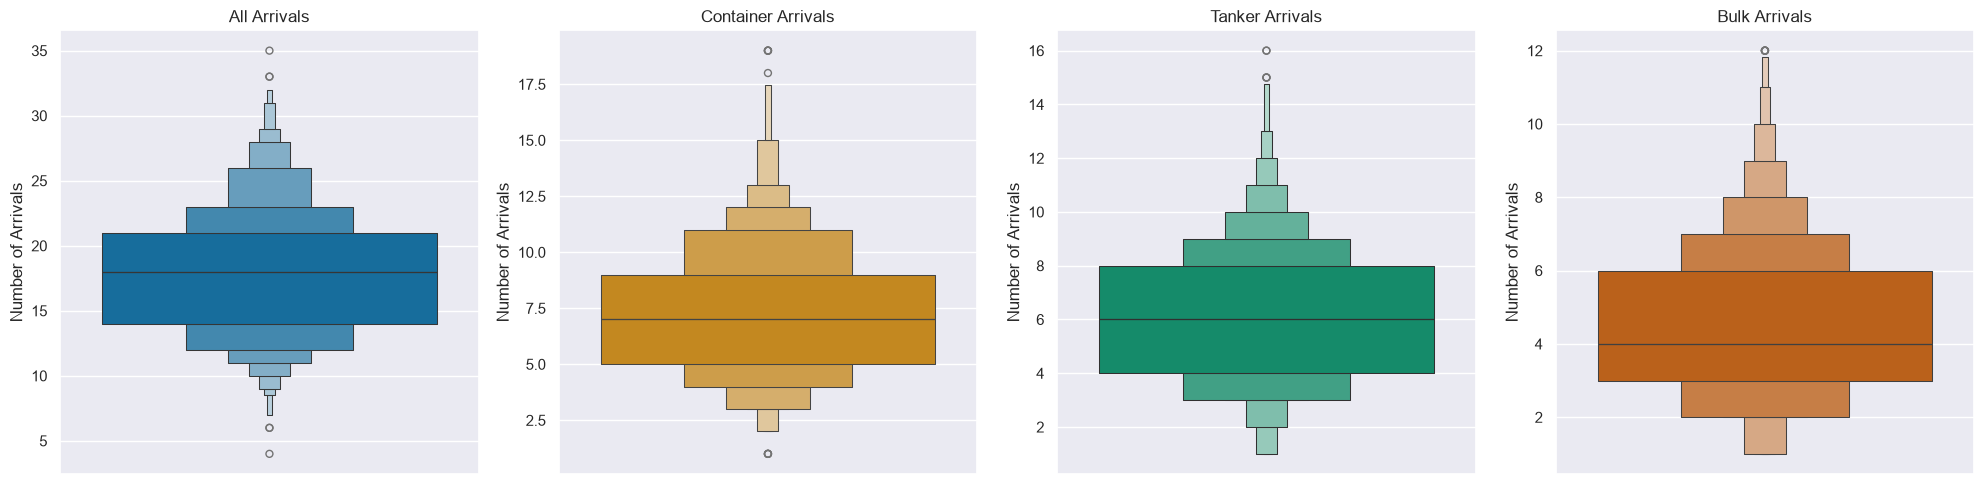

In [13]:
#plots next to each other despite diff scale b/c need space on report
f, ax = plt.subplots(1, 4, figsize = (20, 5))

#boxenplots good for large datasets
sns.boxenplot(y = year_month_day_count, ax = ax[0], color = palette[0])
ax[0].set_title('All Arrivals')
ax[0].set_ylabel('Number of Arrivals')

sns.boxenplot(y = container_day_count, ax = ax[1], color = palette[1])
ax[1].set_title('Container Arrivals')
ax[1].set_ylabel('Number of Arrivals')

sns.boxenplot(y = tanker_day_count, ax = ax[2], color = palette[2])
ax[2].set_title('Tanker Arrivals')
ax[2].set_ylabel('Number of Arrivals')

sns.boxenplot(y = bulk_day_count, ax = ax[3], color = palette[3])
ax[3].set_title('Bulk Arrivals')
ax[3].set_ylabel('Number of Arrivals')

#save/layout
plt.tight_layout()
plt.savefig('figures/arrivalsbox.jpeg', bbox_inches='tight')
plt.show()

In [14]:
print(container_day_count.mean())
print(tanker_day_count.mean())
print(bulk_day_count.mean())

7.3713503649635035
6.15032080659945
4.513059701492537


## Inter-Arrival Rates

In [22]:
arrival = rd['arrival_date'].sort_values()

#convert each date into hours since first arrival
#arrival-arrival = dt then total seconds b/c lowest value then into hours
arrival_time = (arrival - arrival.iloc[0]).dt.total_seconds() / 3600

#np from lecture
inter_arrival_times = np.diff(arrival_time)

In [23]:
def vessel_inter(vessel:str, rd = rd):
    '''filter rd on vessel type and return inter_arrival times for that vessel

    args:
    vessel: str - vessel type
    rd: df - original, default

    return:
    inter_arrival_times: numpy array
    '''
    vessel_filter = rd[rd['vessel_type'] == vessel]
    
    #sort values to get the first arrival 
    arrival = vessel_filter['arrival_date'].sort_values()
    
    #arrival-firstarrival = dt then convert to total seconds from first arrival -> hour
    arrival_time = (arrival - arrival.iloc[0]).dt.total_seconds() / 3600

    #from lecture, difference
    inter_arrival_times = np.diff(arrival_time)
    return inter_arrival_times

container = vessel_inter('Container')
bulk = vessel_inter('Bulk')
tanker = vessel_inter('Tanker')

In [26]:
def method_of_moments(array):
    '''take array, get method of moments exponential

    args:
    array: numpy array (of interarrival times)

    return:
    plt: plot of distribution
    samplemean: sample mean of array
    parameter: calculation for exponential lambda
    '''
    
    df = pd.DataFrame(array)
    
    #bincount should = sqrt of n
    bincount = df.count() ** 0.5
    plt.figure()
    plt.hist(array, bins = int(round(bincount.iloc[0])), rwidth = 10, density = True)
    samplemean = mean(array)
    param = 1/samplemean
    return plt, samplemean, param

container interarrival time ~ exp(0.3073319480526069)
bulk interarrival time ~ exp(0.18403472449008712)
tank interarrival time ~ exp(0.25524710537328954)


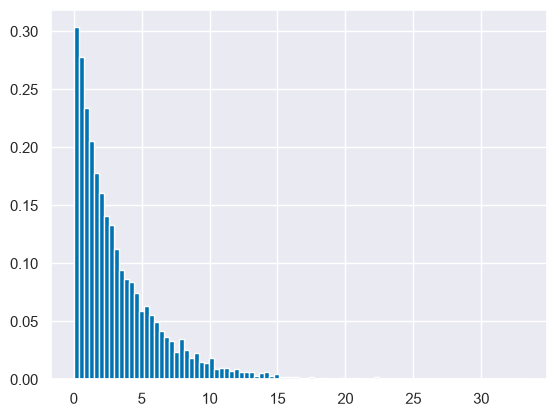

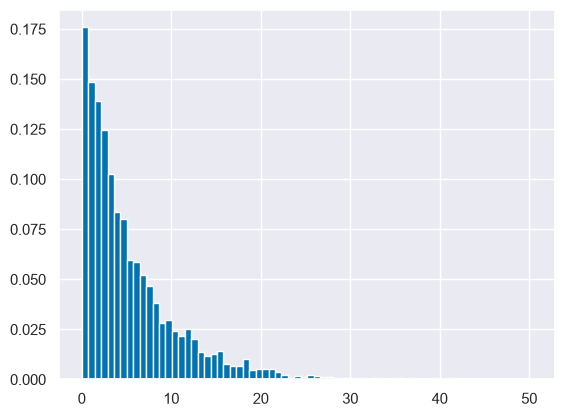

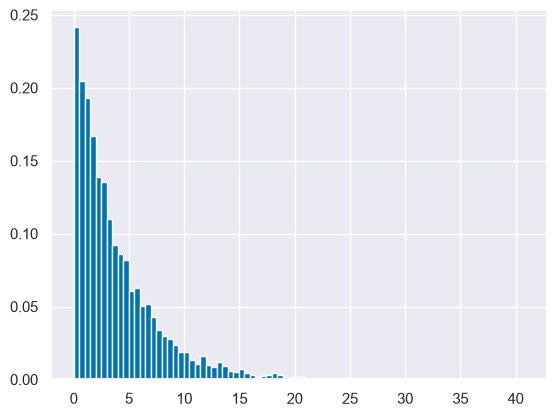

In [27]:
plt_cont, sample_cont, param_cont = method_of_moments(container)

plt_bulk, sample_bulk, param_bulk = method_of_moments(bulk)

plt_tank, sample_tank, param_tank = method_of_moments(tanker)

print(f'container interarrival time ~ exp({param_cont})')
print(f'bulk interarrival time ~ exp({param_bulk})')
print(f'tank interarrival time ~ exp({param_tank})')

In [29]:
inter_df = pd.DataFrame(inter_arrival_times)
print(inter_df.describe())

                  0
count  19626.000000
mean       1.339836
std        1.361788
min        0.000000
25%        0.366667
50%        0.916667
75%        1.866667
max       18.366667


In [34]:
#wip
join_arrival = inter_df.join(arrival)
join_arrival = join_arrival.rename(columns = {0: 'inter_arrival'})
print((inter_df.count())**0.5)

samplemean = mean(inter_arrival_times)

0    140.092826
dtype: float64


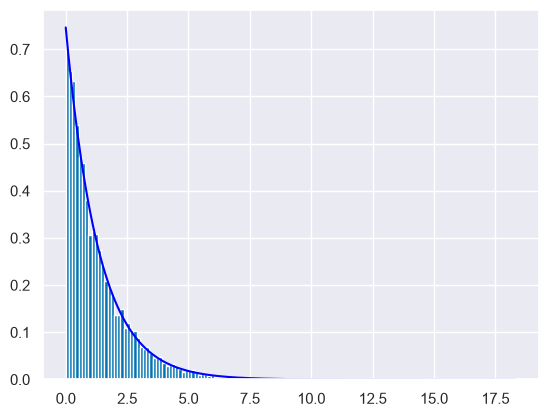

In [38]:
bin = (inter_df.count())**0.5
estlambda = 1/samplemean
#figure out rest later
plt.figure()
plt.hist(inter_arrival_times, bins = 140, rwidth = 10, density = True)
fitExpDist = stats.expon(scale = 1/estlambda)
xs = np.arange(min(inter_arrival_times), max(inter_arrival_times), 0.1)
ys = fitExpDist.pdf(xs)
plt.plot(xs, ys, color = 'blue')
plt.set_axes
plt.show()